# Semantic Log Debugger (Final Advanced)
This notebook improves robustness, extensibility, and advanced RCA for HDFS logs.
- modular pipeline
- multiple anomaly strategies
- causal inference + graph analytics
- evaluation + explainability artifacts

In [1]:
# Install and import dependencies (run once)
import os, sys, json, re, logging, math
from pathlib import Path
import numpy as np, pandas as pd
import networkx as nx, faiss
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sentence_transformers import SentenceTransformer
from pyvis.network import Network
from IPython.display import display, IFrame
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
# Paths
ROOT = Path('.')
INPUT_DIR = ROOT / 'dataset'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
DATASET_FILE = INPUT_DIR / 'HDFS_2k.log_structured.csv'
TRACE_FILE = OUTPUT_DIR / 'structured_traces.json'
TEMPLATES_FILE = OUTPUT_DIR / 'extracted_templates.json'
ANOMALIES_FILE = OUTPUT_DIR / 'anomalous_traces.json'
RCA_FILE = OUTPUT_DIR / 'rca_results.json'
FAISS_INDEX_FILE = OUTPUT_DIR / 'faiss_index.bin'
MAPPING_FILE = OUTPUT_DIR / 'template_mapping.json'
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger('SemanticLogDebugger')

In [7]:
# Pipeline implementation
class SemanticLogDebugger:
    """Semantic log debugging pipeline with embedding, anomaly detection, and root-cause analysis."""

    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2', device='cpu'):
        """Initialize model and in-memory containers."""
        self.model_name = model_name
        self.device = device
        self.model = SentenceTransformer(model_name, device=device)
        self.traces = {}            # raw mapping: blk_id -> [event template text]
        self.templates = {}         # template_id str -> template text
        self.rev_map = {}           # template text -> template_id int
        self.structured_traces = {} # blk_id -> [template_id int]
        self.index = None           # FAISS index
        self.ids = []               # ordered template ids corresponding to embeddings
        self.embeddings = None
        self.anomalies = {}
        self.rca_results = {}

    @staticmethod
    def extract_block_id(content: str) -> str:
        """Extract blk_* identifier from raw log content."""
        m = re.search(r'(blk_-?\d+)', str(content))
        return m.group(1) if m else None

    def load_data(self, path: Path):
        """Load structured log dataset and build trace/template mappings."""
        logger.info('Loading dataset from %s', path)
        df = pd.read_csv(path)

        grouped = defaultdict(list)
        for _, row in df.iterrows():
            block_id = self.extract_block_id(row['Content'])
            if block_id:
                grouped[block_id].append(row['EventTemplate'])

        self.traces = dict(grouped)

        unique_templates = sorted({template for seq in self.traces.values() for template in seq})
        self.templates = {str(i): tmpl for i, tmpl in enumerate(unique_templates)}
        self.rev_map = {tmpl: i for i, tmpl in enumerate(unique_templates)}

        self.structured_traces = {
            block_id: [self.rev_map[tmpl] for tmpl in seq]
            for block_id, seq in self.traces.items()
        }

        PATHS = {
            TRACE_FILE: self.structured_traces,
            TEMPLATES_FILE: self.templates
        }
        for p, data in PATHS.items():
            Path(p).write_text(json.dumps(data, indent=2))

        logger.info('Loaded %d traces and %d templates', len(self.structured_traces), len(self.templates))

    def embed_templates(self, batch_size=64, normalize=True):
        """Create sentence embeddings for templates and index with FAISS."""
        self.texts = [self.templates[key] for key in sorted(self.templates, key=int)]
        self.ids = [int(x) for x in sorted(self.templates, key=int)]

        self.embeddings = self.model.encode(
            self.texts,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=normalize
        ).astype('float32')

        dim = self.embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dim) if normalize else faiss.IndexFlatL2(dim)
        self.index.add(self.embeddings)

        faiss.write_index(self.index, str(FAISS_INDEX_FILE))
        Path(MAPPING_FILE).write_text(json.dumps({i: t_id for i, t_id in enumerate(self.ids)}, indent=2))
        logger.info('FAISS index built with dim=%d and saved: %s', dim, FAISS_INDEX_FILE)

    def search_similar(self, queries, k=10, threshold=0.7):
        """Lookup template IDs similar to query strings using FAISS."""
        if self.index is None:
            raise RuntimeError('FAISS index is not built. Call embed_templates().')

        query_embeddings = self.model.encode(
            queries,
            convert_to_numpy=True,
            normalize_embeddings=True
        ).astype('float32')

        scores, neighbors = self.index.search(query_embeddings, k)

        results = []
        for qi, query in enumerate(queries):
            matched = []
            for rank in range(k):
                score = float(scores[qi][rank])
                if score >= threshold:
                    neighbor_idx = int(neighbors[qi][rank])
                    template_id = self.ids[neighbor_idx]
                    matched.append((template_id, self.templates[str(template_id)], score))
            results.append((query, matched))

        return results

    def detect_anomalies(self, error_queries=None, iforest_contamination=0.01):
        """Detect anomalous traces by semantic matching and unsupervised sequence outliers."""
        if error_queries is None:
            error_queries = [
                'Connection timeout',
                'Block missing or corrupted',
                'Fatal error',
                'Network exception',
                'OutOfMemoryError'
            ]

        semantic_matches = self.search_similar(error_queries, k=20, threshold=0.65)
        error_template_ids = {
            template_id
            for _, matched_templates in semantic_matches
            for template_id, _, _ in matched_templates
        }

        logger.info('Error template IDs found by semantic query: %s', sorted(error_template_ids))

        anomalies = {}
        for block_id, seq in self.structured_traces.items():
            matching_errors = [t_id for t_id in seq if t_id in error_template_ids]
            if matching_errors:
                anomalies[block_id] = {
                    'seq': seq,
                    'err_ids': sorted(set(matching_errors)),
                    'detection': 'semantic'
                }

        if self.structured_traces:
            docs = [' '.join(str(x) for x in seq) for seq in self.structured_traces.values()]
            X = TfidfVectorizer(max_features=4096).fit_transform(docs).toarray()
            isolation_forest = IsolationForest(n_estimators=200, contamination=iforest_contamination, random_state=42)
            outlier_flags = isolation_forest.fit_predict(X)

            for idx, (block_id, seq) in enumerate(self.structured_traces.items()):
                if outlier_flags[idx] == -1 and block_id not in anomalies:
                    anomalies[block_id] = {
                        'seq': seq,
                        'err_ids': [],
                        'detection': 'unsupervised'
                    }

        self.anomalies = anomalies
        Path(ANOMALIES_FILE).write_text(json.dumps(self.anomalies, indent=2))
        logger.info('Detected %d anomalies', len(self.anomalies))
        return self.anomalies

    def perform_rca(self):
        """Create one DAG per anomalous trace and pick root cause by PageRank."""
        if not self.anomalies:
            raise RuntimeError('No anomalies found. Run detect_anomalies first.')

        rca_results = {}
        for block_id, data in self.anomalies.items():
            seq = data['seq']
            if not seq:
                rca_results[block_id] = {'seq': [], 'err_ids': data.get('err_ids', []), 'rc_id': None, 'explanation': 'empty trace'}
                continue

            G = nx.DiGraph(((seq[i], seq[i + 1]) for i in range(len(seq) - 1)))

            if G.number_of_edges() == 0:
                chosen = seq[0]
                explanation = 'singleton trace'
            else:
                try:
                    pagerank_scores = nx.pagerank(G, alpha=0.85)
                    chosen = max(pagerank_scores, key=pagerank_scores.get)
                    explanation = 'root by PageRank'
                except Exception as exc:
                    logger.warning('PageRank failed for %s: %s', block_id, exc)
                    chosen = seq[0]
                    explanation = 'fallback first event'

            rca_results[block_id] = {
                'seq': seq,
                'err_ids': data.get('err_ids', []),
                'rc_id': chosen,
                'explanation': explanation
            }

        self.rca_results = rca_results
        Path(RCA_FILE).write_text(json.dumps(self.rca_results, indent=2))
        return self.rca_results

    def visualize(self, top_n=20):
        """Visualize top root causes and show interactive causal graph."""
        if not self.rca_results:
            raise RuntimeError('No RCA results. Run perform_rca first.')

        root_counts = Counter(res['rc_id'] for res in self.rca_results.values() if res.get('rc_id') is not None)
        top_root = root_counts.most_common(top_n)

        df = pd.DataFrame([
            {'rc_id': rc_id, 'count': cnt, 'template': self.templates.get(str(rc_id), f'Template {rc_id}')}
            for rc_id, cnt in top_root
        ])

        display(df)

        plt.figure(figsize=(10, 6))
        bars = plt.barh(df['template'][::-1], df['count'][::-1], color='#264653')
        plt.title('Top Root Cause Templates')
        plt.xlabel('Occurrence Count')
        plt.tight_layout()
        for bar in bars:
            value = int(bar.get_width())
            plt.text(value + 0.2, bar.get_y() + bar.get_height() / 2, str(value), va='center')
        plt.show()

        net = Network(height='700px', width='100%', directed=True, notebook=True)
        for block_id, data in list(self.rca_results.items())[:min(50, len(self.rca_results))]:
            seq = data['seq']
            err_ids = set(data.get('err_ids', []))
            rc_id = data.get('rc_id')
            self._add_sequence_to_network(net, block_id, seq, err_ids, rc_id)

        output_path = OUTPUT_DIR / 'rca_graph_final.html'
        net.show(str(output_path))
        display(IFrame(src=str(output_path), width='100%', height='700px'))
        logger.info('Saved interactive graph at %s', output_path)

    def _add_sequence_to_network(self, net, block_id, seq, err_ids, rc_id):
        """Render a single trace sequence in the interactive network graph."""
        for idx, template_id in enumerate(seq):
            template_label = self.templates.get(str(template_id), f'Template {template_id}')
            is_root = (template_id == rc_id)
            is_error = (template_id in err_ids)

            color = '#d62828' if is_error else ('#2a9d8f' if is_root else '#8ecae6')
            size = 70 if is_root else 30
            label = f'{"ROOT " if is_root else ""}{template_label}'

            net.add_node(f'{block_id}_{template_id}_{idx}', label=label, title=template_label, color=color, size=size)
            if idx > 0:
                prev_node = f'{block_id}_{seq[idx-1]}_{idx-1}'
                current_node = f'{block_id}_{template_id}_{idx}'
                net.add_edge(prev_node, current_node, color='#075985')

2026-04-03 18:43:39,727 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
c:\1Data\Ved_Data\AmritaCSE\Research\Research_Sem5\ML_DL_FetusScan\ML_Endsem\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-04-03 18:43:43,041 - INFO - Loading dataset from dataset\HDFS_2k.log_structured.csv
2026-04-03 18:43:43,120 - INFO - Loaded 1994 traces and 14 templates


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-03 18:43:43,206 - INFO - FAISS index built with dim=384 and saved: outputs\faiss_index.bin


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-03 18:43:43,239 - INFO - Error template IDs found by semantic query: []
2026-04-03 18:43:43,499 - INFO - Detected 20 anomalies


Total anomalies detected: 20
  semantic-based: 0
  unsupervised-based: 20
 1. block=blk_-1383276859207001328, anomaly_type=unsupervised, errors=0, templates=[]
 2. block=blk_-1547954353065580372, anomaly_type=unsupervised, errors=0, templates=[]
 3. block=blk_-2827716238972737794, anomaly_type=unsupervised, errors=0, templates=[]
 4. block=blk_-4117999745005013424, anomaly_type=unsupervised, errors=0, templates=[]
 5. block=blk_-4980916519894289629, anomaly_type=unsupervised, errors=0, templates=[]
 6. block=blk_-4984504651603069357, anomaly_type=unsupervised, errors=0, templates=[]
 7. block=blk_-6160667975382232149, anomaly_type=unsupervised, errors=0, templates=[]
 8. block=blk_-7803343374223161433, anomaly_type=unsupervised, errors=0, templates=[]
 9. block=blk_-8050165297538775793, anomaly_type=unsupervised, errors=0, templates=[]
10. block=blk_-8347949825960763812, anomaly_type=unsupervised, errors=0, templates=[]
Total RCA entries: 20


,block_id,position,template_id,template,is_root,is_error,rc_id,detection
5,blk_-1383276859207001328,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
2,blk_-1547954353065580372,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
1,blk_-2827716238972737794,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
6,blk_-4117999745005013424,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
0,blk_-4980916519894289629,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
10,blk_-4984504651603069357,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
17,blk_-6160667975382232149,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
11,blk_-7803343374223161433,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
18,blk_-8050165297538775793,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised
19,blk_-8347949825960763812,0,13,Verification succeeded for blk_<*>,True,False,13,unsupervised


,rc_id,count,template
0,13,20,Verification succeeded for blk_<*>


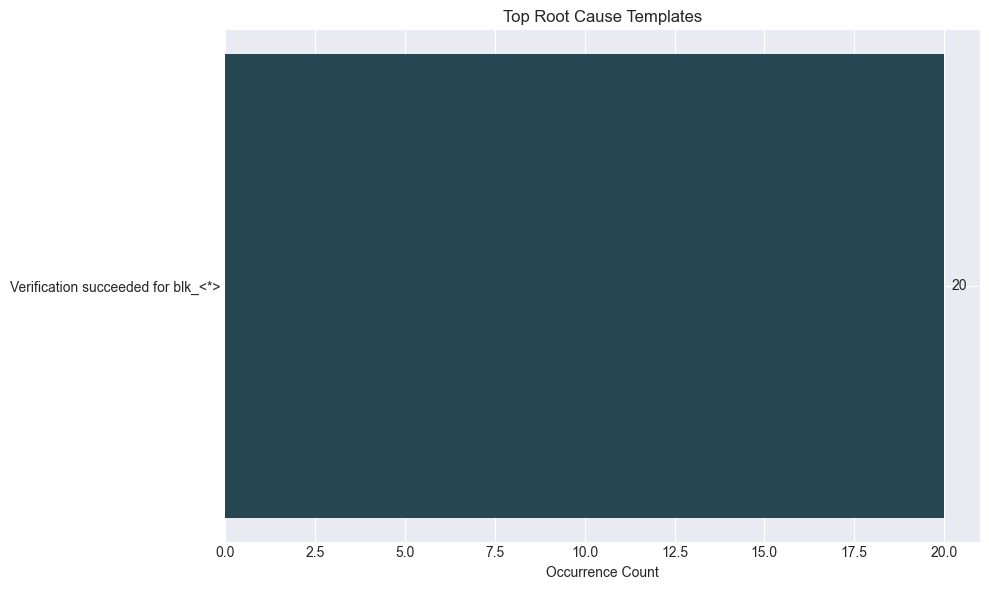

outputs\rca_graph_final.html


2026-04-03 18:43:43,612 - INFO - Saved interactive graph at outputs\rca_graph_final.html


In [15]:
# Run full pipeline and detect anomalies across full dataset
pipeline = SemanticLogDebugger()
pipeline.load_data(DATASET_FILE)
pipeline.embed_templates()
anomalies = pipeline.detect_anomalies()

print(f"Total anomalies detected: {len(anomalies)}")
semantic_cnt = sum(1 for v in anomalies.values() if v.get('detection') == 'semantic')
unsupervised_cnt = sum(1 for v in anomalies.values() if v.get('detection') == 'unsupervised')
print(f"  semantic-based: {semantic_cnt}")
print(f"  unsupervised-based: {unsupervised_cnt}")

# show first 10 anomaly traces and their error templates
for i, (block_id, info) in enumerate(sorted(anomalies.items())[:10]):
    templates = [pipeline.templates.get(str(t_id), f'Template {t_id}') for t_id in info.get('err_ids', [])]
    print(f"{i+1:2d}. block={block_id}, anomaly_type={info.get('detection')}, errors={len(info.get('err_ids', []))}, templates={templates}")

# Continue RCA + viz
tot_rca = pipeline.perform_rca()
print(f"Total RCA entries: {len(tot_rca)}")

# Node-level root cause mapping (for visualization and debugging):
node_rca = []
for block_id, entry in pipeline.rca_results.items():
    for idx, node_id in enumerate(entry['seq']):
        node_rca.append({
            'block_id': block_id,
            'position': idx,
            'template_id': node_id,
            'template': pipeline.templates.get(str(node_id), f'Template {node_id}'),
            'is_root': node_id == entry.get('rc_id'),
            'is_error': node_id in entry.get('err_ids', []),
            'rc_id': entry.get('rc_id'),
            'detection': pipeline.anomalies.get(block_id, {}).get('detection')
        })

node_rca_df = pd.DataFrame(node_rca)
if not node_rca_df.empty:
    display(node_rca_df.sort_values(['is_root', 'rc_id', 'block_id'], ascending=[False, True, True]).head(100))

pipeline.visualize()